In [2]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
db = wrds.Connection()

Loading library list...
Done


In [4]:
query = '''
select tic, fyear, revt, ni, gp, seq, at
from comp.funda
where tic in ('AAPL','MSFT','GOOGL')
and fyear between 2019 and 2023
order by tic, fyear;
'''

data = db.raw_sql(query)

In [5]:
data = data.dropna()
data.head()

,tic,fyear,revt,ni,gp,seq,at
0,AAPL,2019,260174.0,55256.0,109692.0,90488.0,338516.0
2,AAPL,2020,274515.0,57411.0,114656.0,65339.0,323888.0
4,AAPL,2021,365817.0,94680.0,162336.0,63090.0,351002.0
6,AAPL,2022,394328.0,99803.0,179482.0,50672.0,352755.0
8,AAPL,2023,383285.0,96995.0,177648.0,62146.0,352583.0


In [6]:
data.groupby('tic').head()

,tic,fyear,revt,ni,gp,seq,at
0,AAPL,2019,260174.0,55256.0,109692.0,90488.0,338516.0
2,AAPL,2020,274515.0,57411.0,114656.0,65339.0,323888.0
4,AAPL,2021,365817.0,94680.0,162336.0,63090.0,351002.0
6,AAPL,2022,394328.0,99803.0,179482.0,50672.0,352755.0
8,AAPL,2023,383285.0,96995.0,177648.0,62146.0,352583.0
10,GOOGL,2019,161857.0,34343.0,101612.0,201442.0,275909.0
12,GOOGL,2020,182527.0,40269.0,111474.0,222544.0,319616.0
14,GOOGL,2021,257637.0,76033.0,159128.0,251635.0,359268.0
16,GOOGL,2022,282836.0,59972.0,172562.0,256144.0,365264.0
18,GOOGL,2023,307394.0,73795.0,186487.0,281079.0,402392.0


In [7]:
data['Revenue'] = data['revt']

In [8]:
data['NetIncome'] = data['ni']

In [9]:
data['GrossProfitMargin'] = data['gp'] / data['revt']

In [10]:
data['ROE'] = data['ni'] / data['seq']

In [11]:
data.groupby('tic').head()

,tic,fyear,revt,ni,gp,seq,at,Revenue,NetIncome,GrossProfitMargin,ROE
0,AAPL,2019,260174.0,55256.0,109692.0,90488.0,338516.0,260174.0,55256.0,0.42161,0.610645
2,AAPL,2020,274515.0,57411.0,114656.0,65339.0,323888.0,274515.0,57411.0,0.417668,0.878664
4,AAPL,2021,365817.0,94680.0,162336.0,63090.0,351002.0,365817.0,94680.0,0.443763,1.500713
6,AAPL,2022,394328.0,99803.0,179482.0,50672.0,352755.0,394328.0,99803.0,0.455159,1.969589
8,AAPL,2023,383285.0,96995.0,177648.0,62146.0,352583.0,383285.0,96995.0,0.463488,1.56076
10,GOOGL,2019,161857.0,34343.0,101612.0,201442.0,275909.0,161857.0,34343.0,0.627789,0.170486
12,GOOGL,2020,182527.0,40269.0,111474.0,222544.0,319616.0,182527.0,40269.0,0.610726,0.180948
14,GOOGL,2021,257637.0,76033.0,159128.0,251635.0,359268.0,257637.0,76033.0,0.617644,0.302156
16,GOOGL,2022,282836.0,59972.0,172562.0,256144.0,365264.0,282836.0,59972.0,0.610113,0.234134
18,GOOGL,2023,307394.0,73795.0,186487.0,281079.0,402392.0,307394.0,73795.0,0.606671,0.262542


In [12]:
companies = ['AAPL', 'MSFT', 'GOOGL']

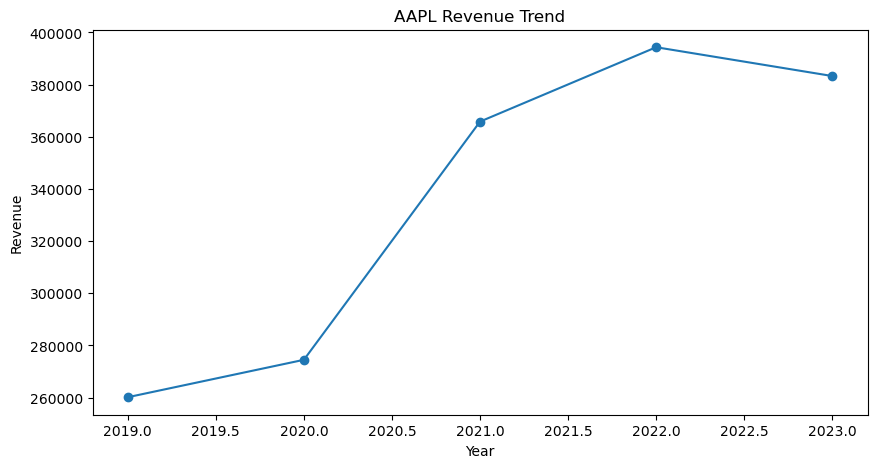

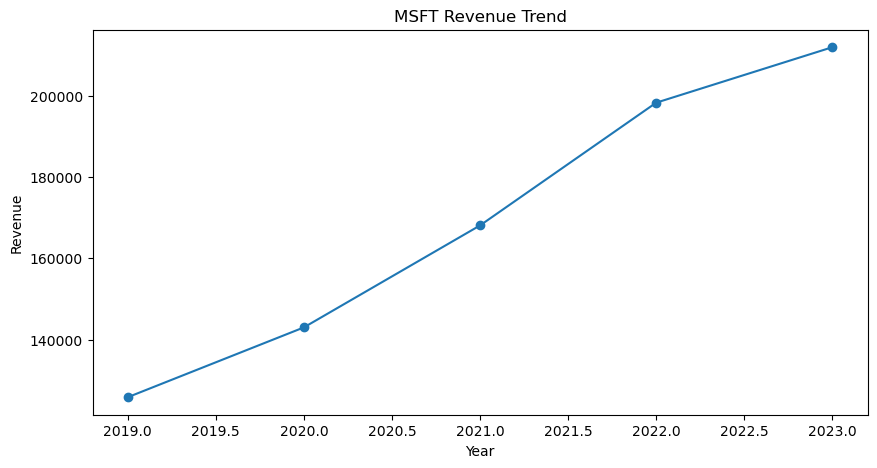

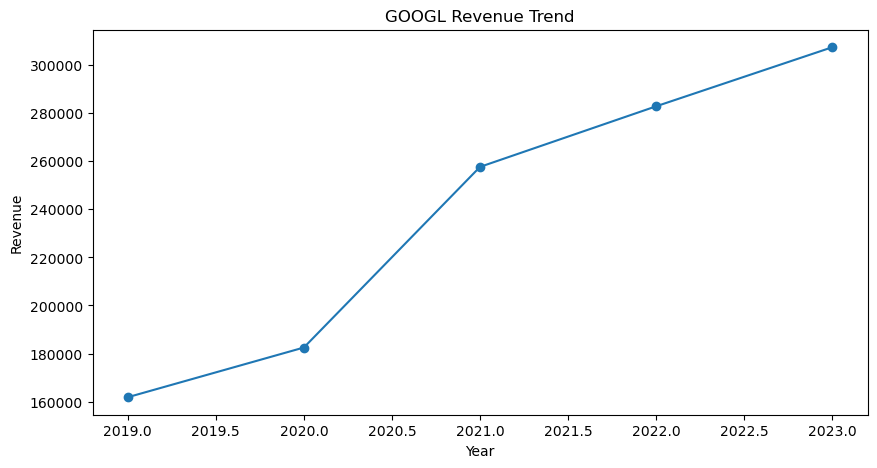

In [13]:
for tick in companies:
    df_single = data[data['tic'] == tick]
    plt.figure(figsize=(10,5))
    plt.plot(df_single['fyear'], df_single['Revenue'], marker='o')
    plt.title(f'{tick} Revenue Trend')
    plt.xlabel('Year')
    plt.ylabel('Revenue')
    plt.show()

In [14]:
print(data.columns.tolist())

['tic', 'fyear', 'revt', 'ni', 'gp', 'seq', 'at', 'Revenue', 'NetIncome', 'GrossProfitMargin', 'ROE']


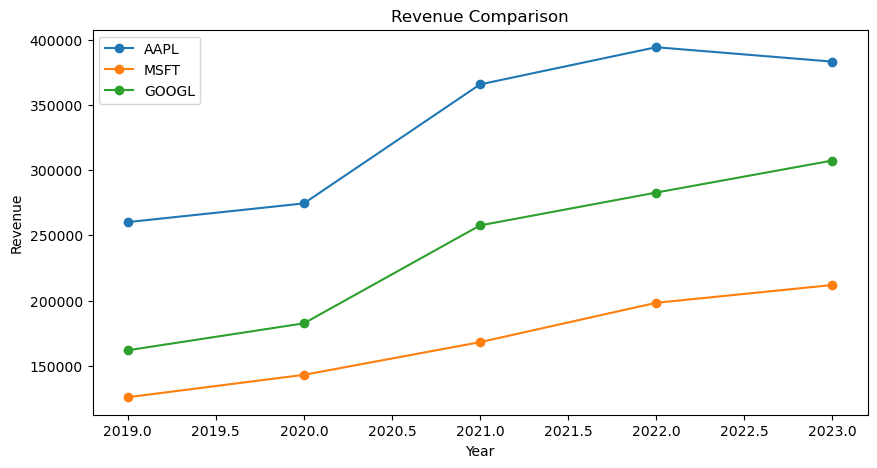

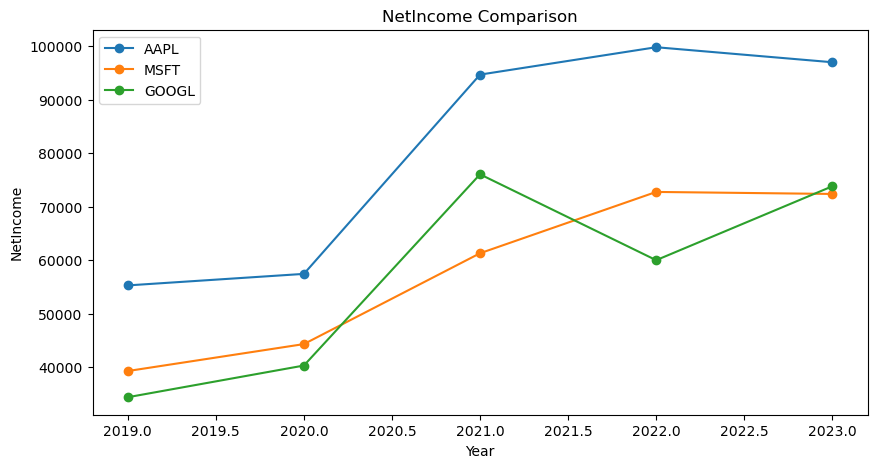

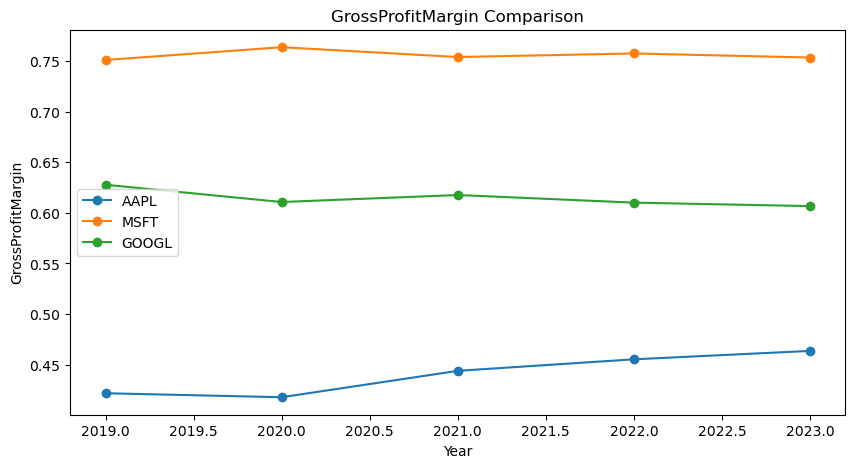

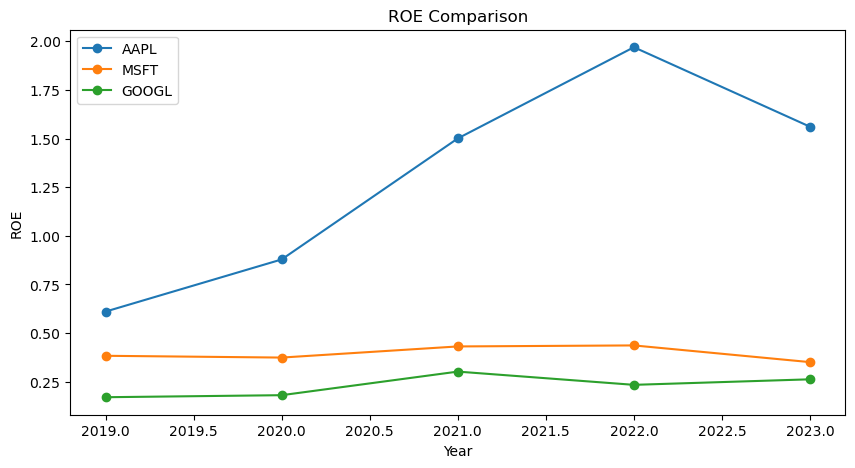

In [15]:
import matplotlib.pyplot as plt

metrics = ['Revenue', 'NetIncome', 'GrossProfitMargin', 'ROE']
companies = ['AAPL', 'MSFT', 'GOOGL']

for metric in metrics:
    plt.figure(figsize=(10,5))
    for tick in companies:
        temp = data[data['tic'] == tick]
        plt.plot(temp['fyear'], temp[metric], marker='o', label=tick)
    
    plt.title(f'{metric} Comparison')
    plt.xlabel('Year')
    plt.ylabel(metric)
    plt.legend()
    plt.show()

In [16]:
db.close()